<a href="https://colab.research.google.com/github/oamerciful-rgb/math-for-data-science/blob/main/COM7024Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the CSV file with latin-1 encoding
# (needed because the file contains the £ symbol)
df = pd.read_csv('Sales Data_PDA_4052 (1).csv', encoding='latin-1')

# First look at the data
print("Shape:", df.shape)          # rows and columns
print("\nFirst 5 rows:")
print(df.head())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Convert date column to proper date format
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Confirm the fix worked
print("\nUpdated Data Types:")
print(df.dtypes)

Shape: (1001, 7)

First 5 rows:
   order_id customer_id sales_person  priority ship_mode        date  \
0      8999        C406        Kelly      High     Plane  12/06/2020   
1     47872        C100        Kelly  Critical     Plane  12/06/2020   
2     29988        C006        Kelly      High     Lorry  12/06/2020   
3     37348        C492        Kelly      High     Plane  13/06/2020   
4     28001        C231        Kelly  Critical     Plane  14/06/2020   

     value_£  
0  £1,553.44  
1    £315.40  
2  £5,075.89  
3    £520.67  
4  £8,431.37  

Data Types:
order_id         int64
customer_id     object
sales_person    object
priority        object
ship_mode       object
date            object
value_£         object
dtype: object

Missing Values:
order_id        0
customer_id     0
sales_person    0
priority        0
ship_mode       0
date            0
value_£         0
dtype: int64

Updated Data Types:
order_id                 int64
customer_id             object
sales_person      

In [3]:
import pandas as pd

# Load the CSV file with latin-1 encoding
df = pd.read_csv('/content/Sales Data_PDA_4052 (1).csv', encoding='latin-1')

# Convert date column to proper date format
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Check current data types before fixing
print("Data types BEFORE correction:")
print(df.dtypes)
print()

# --- Fix 1: value_£ column ---
# Remove the £ symbol and commas, then convert to float
df['value_£'] = df['value_£'].str.replace('£', '', regex=False)
df['value_£'] = df['value_£'].str.replace(',', '', regex=False)
df['value_£'] = df['value_£'].str.strip()
df['value_£'] = df['value_£'].astype(float)

# The date column was already converted above for self-containment, so this line is redundant here.
# --- Fix 2: date column ---
# df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Confirm the fixes worked
print("Data types AFTER correction:")
print(df.dtypes)
print()

# Quick check on the fixed columns
print("Sample of value_£ after fix:")
print(df['value_£'].head())
print()
print("Sample of date after fix:")
print(df['date'].head())

Data types BEFORE correction:
order_id                 int64
customer_id             object
sales_person            object
priority                object
ship_mode               object
date            datetime64[ns]
value_£                 object
dtype: object

Data types AFTER correction:
order_id                 int64
customer_id             object
sales_person            object
priority                object
ship_mode               object
date            datetime64[ns]
value_£                float64
dtype: object

Sample of value_£ after fix:
0    1553.44
1     315.40
2    5075.89
3     520.67
4    8431.37
Name: value_£, dtype: float64

Sample of date after fix:
0   2020-06-12
1   2020-06-12
2   2020-06-12
3   2020-06-13
4   2020-06-14
Name: date, dtype: datetime64[ns]


In [4]:
import pandas as pd

# Load the CSV file with latin-1 encoding
df = pd.read_csv('/content/Sales Data_PDA_4052 (1).csv', encoding='latin-1')

# Convert date column to proper date format
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Remove the £ symbol and commas, then convert to float
df['value_£'] = df['value_£'].str.replace('£', '', regex=False)
df['value_£'] = df['value_£'].str.replace(',', '', regex=False)
df['value_£'] = df['value_£'].str.strip()
df['value_£'] = df['value_£'].astype(float)

# 4.1 Overall Descriptive Statistics
print("=" * 50)
print("4.1 OVERALL DESCRIPTIVE STATISTICS")
print("=" * 50)

print(df['value_£'].describe().round(2))
print(f"\nSkewness: {df['value_£'].skew():.2f}")
print(f"Median: £{df['value_£'].median():.2f}")
print(f"Mean: £{df['value_£'].mean():.2f}")

4.1 OVERALL DESCRIPTIVE STATISTICS
count     1001.00
mean      1778.40
std       3457.46
min          2.45
25%        134.40
50%        417.58
75%       1816.93
max      27448.24
Name: value_£, dtype: float64

Skewness: 3.77
Median: £417.58
Mean: £1778.40


In [5]:
# 4.2 Salesperson Performance
print("\n" + "=" * 50)
print("4.2 SALESPERSON PERFORMANCE")
print("=" * 50)

# Total revenue per salesperson
total = df.groupby('sales_person')['value_£'].sum().round(2)
print("\nTotal Revenue:")
print(total)


4.2 SALESPERSON PERFORMANCE

Total Revenue:
sales_person
Kelly    558659.62
Peter    549292.06
Pryia    672228.97
Name: value_£, dtype: float64


In [6]:
# Mean transaction value per salesperson
mean_val = df.groupby('sales_person')['value_£'].mean().round(2)
print("\nMean Transaction Value:")
print(mean_val)



Mean Transaction Value:
sales_person
Kelly    1751.28
Peter    1596.78
Pryia    1988.84
Name: value_£, dtype: float64


In [7]:
# Number of transactions per salesperson
count = df.groupby('sales_person')['value_£'].count()
print("\nNumber of Transactions:")
print(count)


Number of Transactions:
sales_person
Kelly    319
Peter    344
Pryia    338
Name: value_£, dtype: int64


In [8]:
# Combined summary table
summary = df.groupby('sales_person')['value_£'].agg(
    Total='sum',
    Mean='mean',
    Count='count',
    Max='max'
).round(2)
print("\nFull Summary Table:")
print(summary)


Full Summary Table:
                  Total     Mean  Count       Max
sales_person                                     
Kelly         558659.62  1751.28    319  27448.24
Peter         549292.06  1596.78    344  26514.97
Pryia         672228.97  1988.84    338  24911.40



4.4 PRIORITY DISTRIBUTION

Order Count by Priority:
priority
Critical         221
Not Specified    213
Low              200
High             196
Medium           171
Name: count, dtype: int64

Percentage Breakdown:
priority
Critical         22.1
Not Specified    21.3
Low              20.0
High             19.6
Medium           17.1
Name: proportion, dtype: float64

Mean Sale Value by Priority:
priority
Critical         1826.48
High             1946.65
Low              1462.68
Medium           1931.80
Not Specified    1747.00
Name: value_£, dtype: float64


/tmp/ipykernel_14428/2850663912.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,


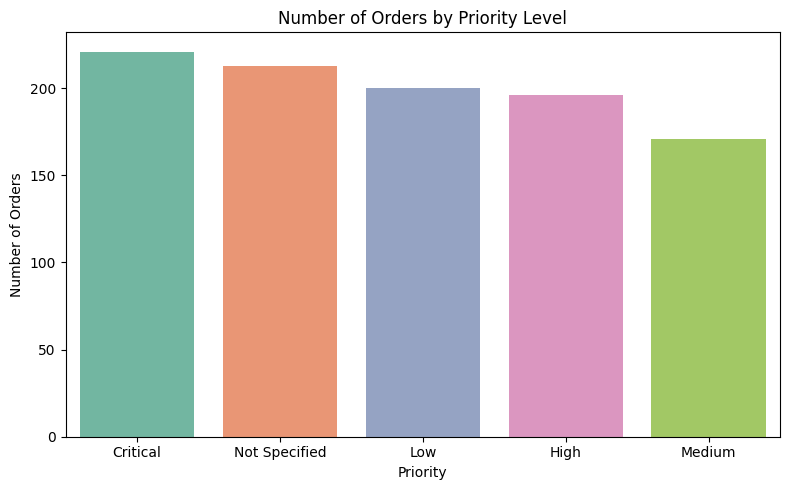

/tmp/ipykernel_14428/2850663912.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


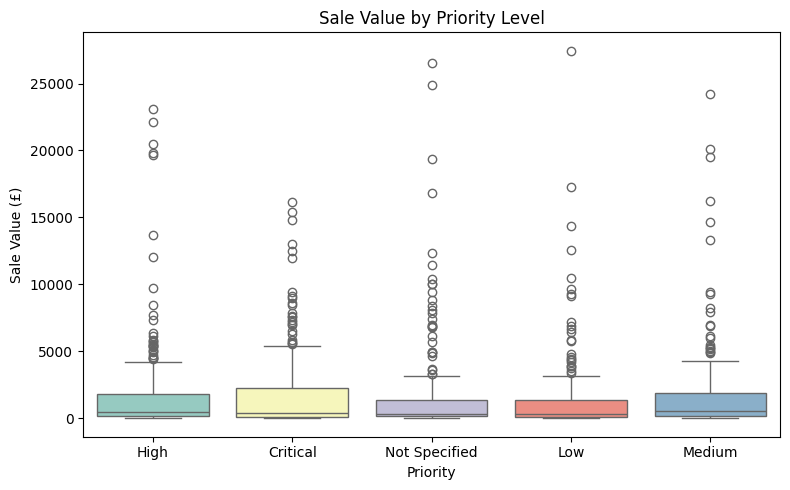

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4.4 Priority Distribution
print("\n" + "=" * 50)
print("4.4 PRIORITY DISTRIBUTION")
print("=" * 50)

# Count of orders per priority
priority_count = df['priority'].value_counts()
print("\nOrder Count by Priority:")
print(priority_count)

# Percentage breakdown
priority_pct = df['priority'].value_counts(normalize=True) * 100
print("\nPercentage Breakdown:")
print(priority_pct.round(1))

# Mean sale value per priority
priority_mean = df.groupby('priority')['value_£'].mean().round(2)
print("\nMean Sale Value by Priority:")
print(priority_mean)

# Bar chart of priority counts
plt.figure(figsize=(8, 5))
sns.countplot(data=df,
              x='priority',
              order=priority_count.index,
              palette='Set2')
plt.title('Number of Orders by Priority Level')
plt.xlabel('Priority')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('priority_dist.png')
plt.show()

# Boxplot of sale value by priority
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,
            x='priority',
            y='value_£',
            palette='Set3')
plt.title('Sale Value by Priority Level')
plt.xlabel('Priority')
plt.ylabel('Sale Value (£)')
plt.tight_layout()
plt.savefig('priority_value.png')
plt.show()

Q1: £134.40
Q3: £1816.93
IQR: £1682.53

Lower Boundary: £-2389.39
Upper Boundary: £4340.73

Number of outliers found: 122
Outliers below lower boundary: 0
Outliers above upper boundary: 122

Rows before removal: 1001
Rows after removal:  879
Rows removed:        122

Skewness before: 3.77
Skewness after:  1.76


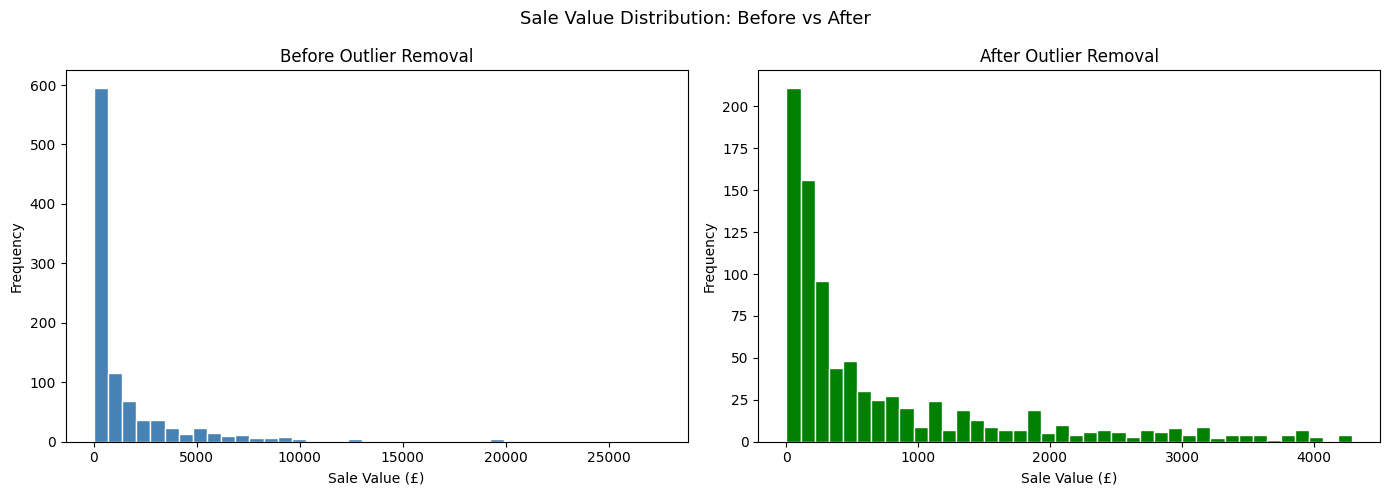

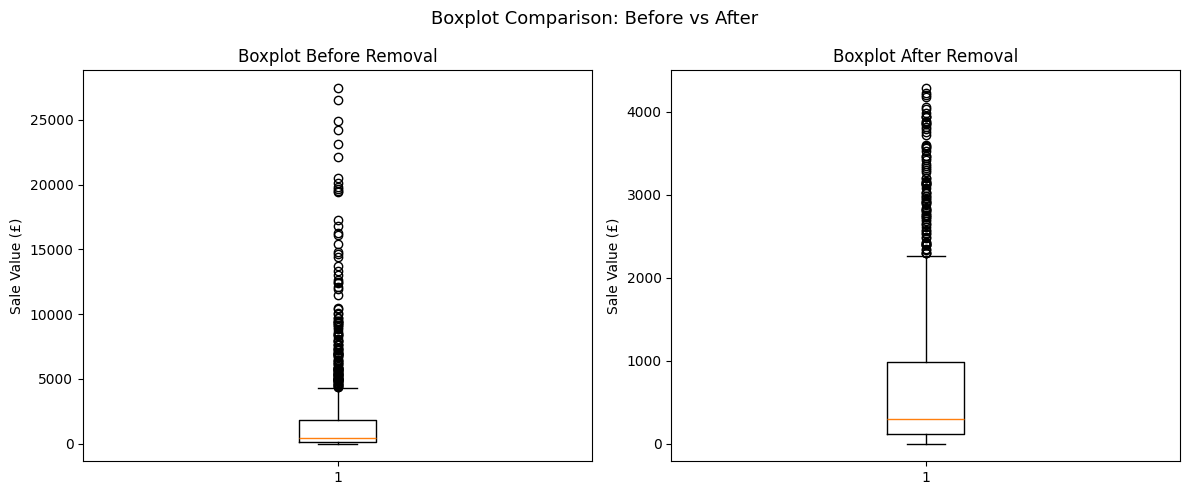

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file with latin-1 encoding
df = pd.read_csv('/content/Sales Data_PDA_4052 (1).csv', encoding='latin-1')

# Convert date column to proper date format
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Remove the £ symbol and commas, then convert to float
df['value_£'] = df['value_£'].str.replace('£', '', regex=False)
df['value_£'] = df['value_£'].str.replace(',', '', regex=False)
df['value_£'] = df['value_£'].str.strip()
df['value_£'] = df['value_£'].astype(float)

# ─────────────────────────────────────────
# SECTION 5: OUTLIER DETECTION & REMOVAL
# ─────────────────────────────────────────

# Step 1: Calculate Q1, Q3 and IQR
Q1 = df['value_£'].quantile(0.25)
Q3 = df['value_£'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1: £{Q1:.2f}")
print(f"Q3: £{Q3:.2f}")
print(f"IQR: £{IQR:.2f}")

# Step 2: Calculate boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nLower Boundary: £{lower_bound:.2f}")
print(f"Upper Boundary: £{upper_bound:.2f}")

# Step 3: Count outliers
outliers = df[
    (df['value_£'] < lower_bound) |
    (df['value_£'] > upper_bound)
]
print(f"\nNumber of outliers found: {len(outliers)}")
print(f"Outliers below lower boundary: "
      f"{len(df[df['value_£'] < lower_bound])}")
print(f"Outliers above upper boundary: "
      f"{len(df[df['value_£'] > upper_bound])}")

# Step 4: Remove outliers
df_clean = df[
    (df['value_£'] >= lower_bound) &
    (df['value_£'] <= upper_bound)
].copy()

print(f"\nRows before removal: {len(df)}")
print(f"Rows after removal:  {len(df_clean)}")
print(f"Rows removed:        {len(df) - len(df_clean)}")

# Step 5: Compare skewness before and after
skew_before = df['value_£'].skew()
skew_after  = df_clean['value_£'].skew()

print(f"\nSkewness before: {skew_before:.2f}")
print(f"Skewness after:  {skew_after:.2f}")

# Step 6: Side by side histogram comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['value_£'], bins=40,
             color='steelblue', edgecolor='white')
axes[0].set_title('Before Outlier Removal')
axes[0].set_xlabel('Sale Value (£)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_clean['value_£'], bins=40,
             color='green', edgecolor='white')
axes[1].set_title('After Outlier Removal')
axes[1].set_xlabel('Sale Value (£)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Sale Value Distribution: Before vs After',
             fontsize=13)
plt.tight_layout()
plt.savefig('outlier_comparison.png')
plt.show()

# Step 7: Boxplot before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df['value_£'])
axes[0].set_title('Boxplot Before Removal')
axes[0].set_ylabel('Sale Value (£)')

axes[1].boxplot(df_clean['value_£'])
axes[1].set_title('Boxplot After Removal')
axes[1].set_ylabel('Sale Value (£)')

plt.suptitle('Boxplot Comparison: Before vs After',
             fontsize=13)
plt.tight_layout()
plt.savefig('boxplot_comparison.png')
plt.show()

/tmp/ipykernel_30660/3044703817.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total.index,


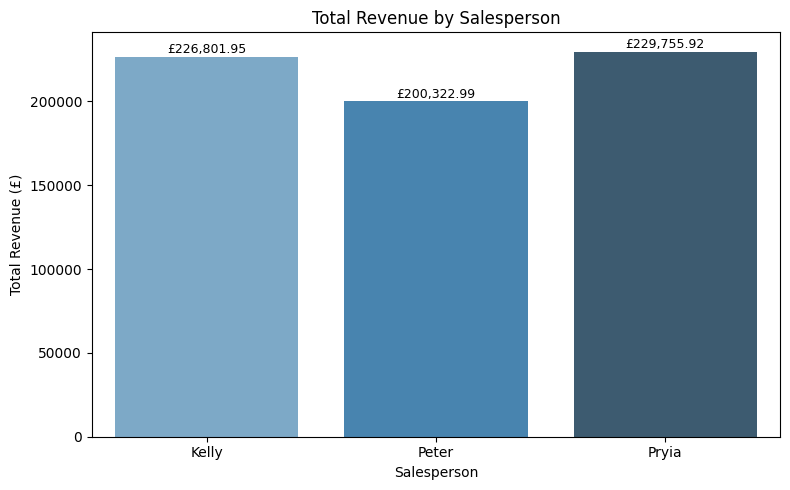

In [8]:
# ─────────────────────────────────────────
# SECTION 6: EDA & GRAPHICAL REPRESENTATION
# ─────────────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns

# ── 6.1 Total Sales by Salesperson ───────
total = df_clean.groupby(
    'sales_person')['value_£'].sum().round(2)

plt.figure(figsize=(8, 5))
sns.barplot(x=total.index,
            y=total.values,
            palette='Blues_d')
plt.title('Total Revenue by Salesperson')
plt.xlabel('Salesperson')
plt.ylabel('Total Revenue (£)')
for i, v in enumerate(total.values):
    plt.text(i, v + 2000,
             f'£{v:,.2f}',
             ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('total_sales.png')
plt.show()

/tmp/ipykernel_30660/3333805531.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sales_person',


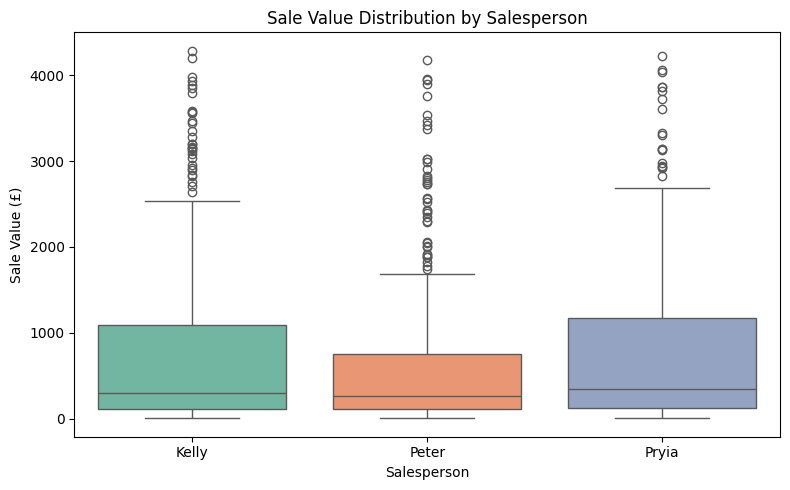

In [9]:
# ── 6.2 Distribution by Salesperson ──────
plt.figure(figsize=(8, 5))
sns.boxplot(x='sales_person',
            y='value_£',
            data=df_clean,
            palette='Set2')
plt.title('Sale Value Distribution by Salesperson')
plt.xlabel('Salesperson')
plt.ylabel('Sale Value (£)')
plt.tight_layout()
plt.savefig('dist_salesperson.png')
plt.show()

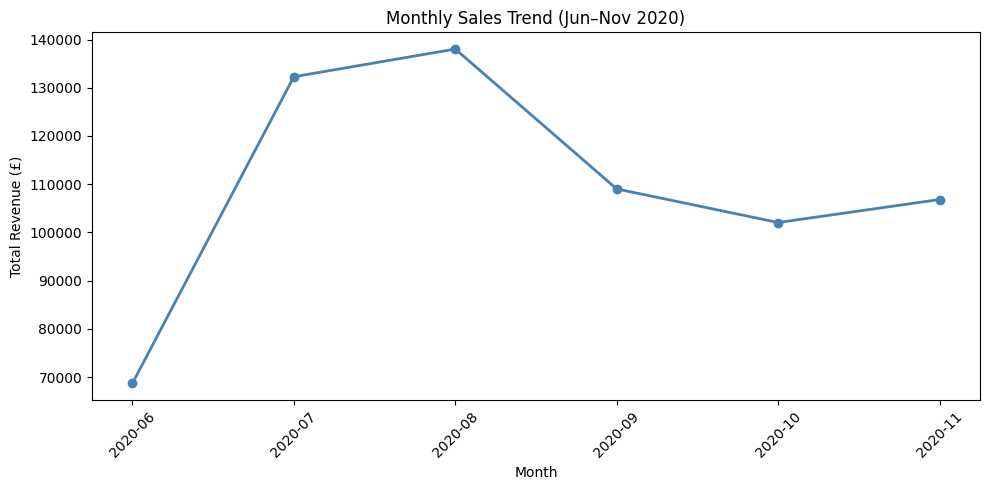

Monthly Revenue:
  month   value_£
2020-06  68687.09
2020-07 132282.79
2020-08 138030.34
2020-09 109011.87
2020-10 102048.78
2020-11 106819.99


In [10]:
# ── 6.3 Monthly Sales Trend ───────────────
# Extract month from date column
df_clean['month'] = df_clean['date'].dt.to_period('M')
monthly = df_clean.groupby(
    'month')['value_£'].sum().reset_index()
monthly['month'] = monthly['month'].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(monthly['month'],
         monthly['value_£'],
         marker='o',
         color='steelblue',
         linewidth=2)
plt.title('Monthly Sales Trend (Jun–Nov 2020)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()

# Print monthly totals
print("Monthly Revenue:")
print(monthly.to_string(index=False))


/tmp/ipykernel_30660/2008631447.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=priority_mean.index,


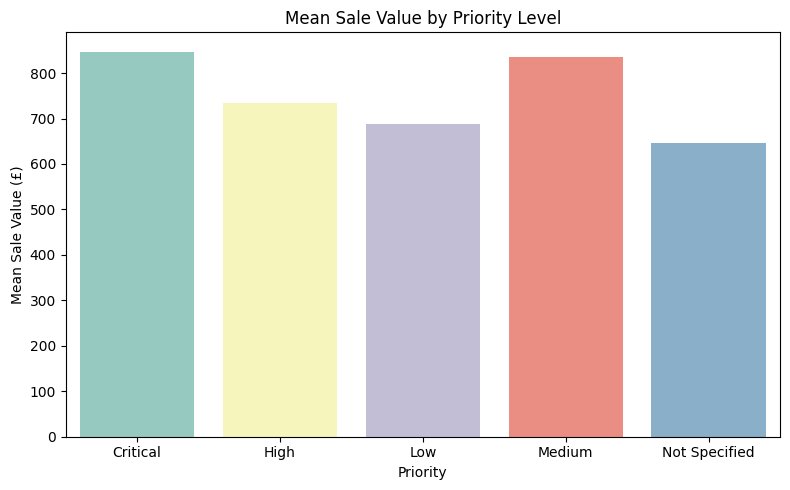


Mean Sale Value by Priority:
priority
Critical         847.26
High             733.17
Low              687.97
Medium           834.97
Not Specified    645.28
Name: value_£, dtype: float64


In [11]:
# ── 6.4 Mean Sale Value by Priority ──────
priority_mean = df_clean.groupby(
    'priority')['value_£'].mean().round(2)

plt.figure(figsize=(8, 5))
sns.barplot(x=priority_mean.index,
            y=priority_mean.values,
            palette='Set3')
plt.title('Mean Sale Value by Priority Level')
plt.xlabel('Priority')
plt.ylabel('Mean Sale Value (£)')
plt.tight_layout()
plt.savefig('mean_priority.png')
plt.show()

print("\nMean Sale Value by Priority:")
print(priority_mean)


/tmp/ipykernel_30660/2290304507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=priority_count.index,


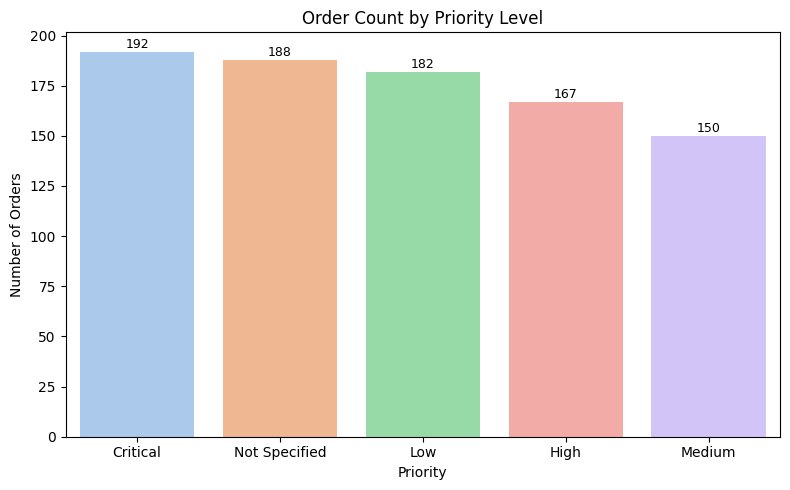


Order Count by Priority:
priority
Critical         192
Not Specified    188
Low              182
High             167
Medium           150
Name: count, dtype: int64


In [12]:
# ── 6.5 Order Count by Priority ──────────
priority_count = df_clean['priority'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=priority_count.index,
            y=priority_count.values,
            palette='pastel')
plt.title('Order Count by Priority Level')
plt.xlabel('Priority')
plt.ylabel('Number of Orders')
for i, v in enumerate(priority_count.values):
    plt.text(i, v + 2,
             str(v),
             ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('order_count.png')
plt.show()

print("\nOrder Count by Priority:")
print(priority_count)


In [4]:
import pandas as pd
from scipy import stats

# Load the CSV file with latin-1 encoding
df = pd.read_csv('/content/Sales Data_PDA_4052 (1).csv', encoding='latin-1')

# Convert date column to proper date format
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Remove the £ symbol and commas, then convert to float
df['value_£'] = df['value_£'].str.replace('£', '', regex=False)
df['value_£'] = df['value_£'].str.replace(',', '', regex=False)
df['value_£'] = df['value_£'].str.strip()
df['value_£'] = df['value_£'].astype(float)

# --- Outlier Detection & Removal (needed to define df_clean) ---
# Calculate Q1, Q3 and IQR
Q1 = df['value_£'].quantile(0.25)
Q3 = df['value_£'].quantile(0.75)
IQR = Q3 - Q1

# Calculate boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers to create df_clean
df_clean = df[
    (df['value_£'] >= lower_bound) &
    (df['value_£'] <= upper_bound)
].copy()

# ─────────────────────────────────────────
# SECTION 7: FURTHER STATISTICAL INVESTIGATIONS
# ─────────────────────────────────────────

# ── 7.1 One-Way ANOVA ────────────────────

# Split sale values by salesperson
kelly = df_clean[
    df_clean['sales_person'] == 'Kelly']['value_£']
peter = df_clean[
    df_clean['sales_person'] == 'Peter']['value_£']
pryia = df_clean[
    df_clean['sales_person'] == 'Pryia']['value_£']

# Run ANOVA
f_stat, p_anova = stats.f_oneway(kelly, peter, pryia)

print("=" * 50)
print("7.1 ONE-WAY ANOVA RESULTS")
print("=" * 50)
print(f"F-statistic: {f_stat:.2f}")
print(f"P-value:     {p_anova:.2f}")

if p_anova < 0.05:
    print("Result: Significant difference found.")
else:
    print("Result: No significant difference between"
          " representatives.")

# Group means for reference
print("\nMean sale value by salesperson:")
print(df_clean.groupby(
    'sales_person')['value_£'].mean().round(2))

7.1 ONE-WAY ANOVA RESULTS
F-statistic: 2.42
P-value:     0.09
Result: No significant difference between representatives.

Mean sale value by salesperson:
sales_person
Kelly    804.26
Peter    650.40
Pryia    795.00
Name: value_£, dtype: float64



7.2 PEARSON CORRELATION RESULTS
r value:  0.069
P-value:  0.04
Result: Significant correlation found.


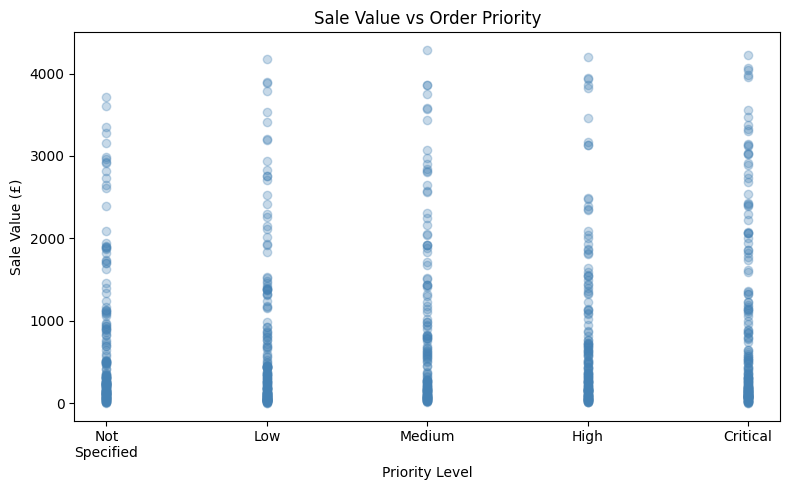

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
# ── 7.2 Pearson Correlation ───────────────

# Convert priority to numeric
priority_map = {
    'Critical':      4,
    'High':          3,
    'Medium':        2,
    'Low':           1,
    'Not Specified': 0
}

df_clean['priority_num'] = df_clean[
    'priority'].map(priority_map)

# Run Pearson correlation
r, p_corr = stats.pearsonr(
    df_clean['priority_num'],
    df_clean['value_£']
)

print("\n" + "=" * 50)
print("7.2 PEARSON CORRELATION RESULTS")
print("=" * 50)
print(f"r value:  {r:.3f}")
print(f"P-value:  {p_corr:.2f}")

if p_corr < 0.05:
    print("Result: Significant correlation found.")
else:
    print("Result: No significant relationship between"
          " priority and sale value.")

# Scatter plot: priority vs sale value
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['priority_num'],
            df_clean['value_£'],
            alpha=0.3,
            color='steelblue')
plt.xticks([0, 1, 2, 3, 4],
           ['Not\nSpecified', 'Low',
            'Medium', 'High', 'Critical'])
plt.title('Sale Value vs Order Priority')
plt.xlabel('Priority Level')
plt.ylabel('Sale Value (£)')
plt.tight_layout()
plt.savefig('correlation_plot.png')
plt.show()